# Gradient Boosting

Train and evaluate a Gradient Boosting classifier on the processed earthquake dataset.

In [11]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [12]:
# Load processed data
data_path = Path("data/processed/earthquake_processed.csv")
if not data_path.exists():
    data_path = Path("../data/processed/earthquake_processed.csv")
if not data_path.exists():
    raise FileNotFoundError(
        "Processed dataset not found. Run `python src/data_prep.py` from the repo root."
    )
df = pd.read_csv(data_path)
df.head()


,latitude,longitude,depth,year,month,day,dayofyear,mag_category
0,-23.4332,-179.8984,547.033,2026,1,7,7,5-5.9
1,7.2863,127.0595,11.854,2026,1,7,7,5-5.9
2,7.3902,126.7221,35.000,2026,1,7,7,6-6.9
3,-17.6276,168.2465,62.384,2026,1,6,6,5-5.9
4,37.2523,74.6137,10.000,2026,1,6,6,5-5.9


In [13]:
# Features and target
X = df.drop(columns=["mag_category"])
y = df["mag_category"]


In [14]:
# Train/test split (random split; use time-based split if needed)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


### Gradient Boosting (Tuned Hyperparameters)

Learning rate and tree depth are set explicitly to control model complexity.


In [15]:
# Train model
model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
)
model.fit(X_train, y_train)


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [16]:
# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

       5-5.9       0.90      0.99      0.94     17750
       6-6.9       0.65      0.26      0.37      2507
          7+       0.55      0.05      0.10       301

    accuracy                           0.88     20558
   macro avg       0.70      0.43      0.47     20558
weighted avg       0.86      0.88      0.86     20558

[[17492   254     4]
 [ 1854   644     9]
 [  193    92    16]]


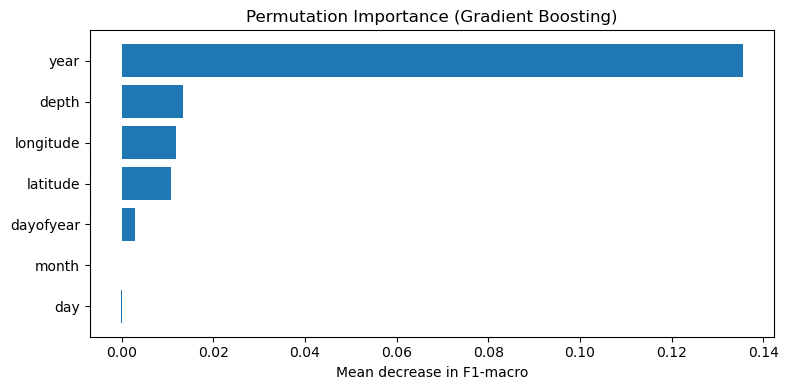

In [17]:
# Permutation Importance (Gradient Boosting)
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro",
)

perm_importance = (
    pd.Series(result.importances_mean, index=X.columns)
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 4))
plt.barh(perm_importance.index, perm_importance.values)
plt.title("Permutation Importance (Gradient Boosting)")
plt.xlabel("Mean decrease in F1-macro")
plt.tight_layout()
plt.show()


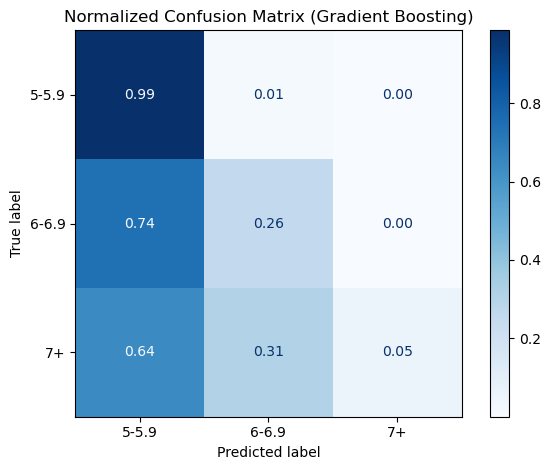

In [18]:
# Confusion Matrix (Normalized)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_order = ["5-5.9", "6-6.9", "7+"]
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=class_order,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
)
plt.title("Normalized Confusion Matrix (Gradient Boosting)")
plt.tight_layout()
plt.show()


In [19]:
# Example Earthquake Testing
eg_earthquake = pd.DataFrame(
    {
        "latitude": [7.7749],
        "longitude": [5.4194],
        "depth": [10.0],
        "year": [2023],
        "month": [1],
        "day": [15],
        "dayofyear": [15],
    }
)

pred_category = model.predict(eg_earthquake)
print(f"Predicted Magnitude Category: {pred_category[0]}")


Predicted Magnitude Category: 5-5.9
